<a href="https://colab.research.google.com/github/satisumit/Soybean-CNN-Analysis/blob/main/notebooks/SBMC_ResNet152.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, callbacks, models
import os, random, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import shutil
import time
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import pandas as pd
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ============================================================================
# STEP 1: SETUP AND DATA LOADING (Using fast local storage copy)
# ============================================================================
print("=" * 70)
print("STEP 1: Setting up environment and fast data loading")
print("=" * 70)

# Mount Google Drive
try:
    drive.mount('/content/drive')
except Exception as e:
    print(f"Drive mount failed: {e}. Ensure you are in a Colab environment.")

# Define paths
gdrive_path = "/content/drive/MyDrive/Datasets/SoybeanImagessplitted/"
local_path = "/root/soybean_data/"
savepath = "/content/drive/MyDrive/Collabs/SoybeanMultiClass_ResNet152/"
os.makedirs(savepath, exist_ok=True)

# Copy data to local Colab storage for faster I/O
if not os.path.exists(local_path):
    print("\n📂 Copying dataset from Google Drive to local Colab storage...")
    start_time = time.time()
    try:
        os.system(f'cp -r "{gdrive_path}" "{local_path}"')
        elapsed = time.time() - start_time
        print(f"✓ Copy complete in {elapsed:.1f} seconds!")
    except Exception:
        print(f"🚨 Local copy failed. Falling back to Google Drive path.")
        local_path = gdrive_path
else:
    print(f"✓ Data already copied to {local_path}")

# Use path (local or drive)
datapath = local_path
train_data_dir = datapath + "train"
val_data_dir = datapath + "val"
test_data_dir = datapath + "test"

STEP 1: Setting up environment and fast data loading
Mounted at /content/drive

📂 Copying dataset from Google Drive to local Colab storage...
✓ Copy complete in 352.9 seconds!


In [ ]:

# ============================================================================
# STEP 2: HYPERPARAMETERS & SEEDING
# ============================================================================

SEED = 1234
dim = (224, 224)
epochs_phase1 = 20  # Initial training epochs
epochs_phase2 = 30 # Fine-tuning epochs
batch_size = 16
classes = 4
initial_learning_rate = 0.0005 # Lowered initial LR for better stability

def seed_all(SEED):
    tf.random.set_seed(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    os.environ['PYTHONHASHSEED'] = str(SEED)

seed_all(SEED)

# Enable mixed precision for faster training on GPUs/TPUs
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f"\n✓ Mixed precision policy set to: {policy.name}")



✓ Mixed precision policy set to: mixed_float16


In [ ]:

# ============================================================================
# STEP 3: CREATE TF.DATA PIPELINE
# ============================================================================
print("\n" + "=" * 70)
print("STEP 3: Creating optimized tf.data pipeline")
print("=" * 70)

def create_dataset(directory, target_size=dim, batch_size=batch_size, shuffle=True):
    """Creates an optimized tf.data pipeline."""
    dataset = tf.keras.utils.image_dataset_from_directory(
        directory,
        seed=SEED,
        image_size=target_size,
        batch_size=batch_size,
        shuffle=shuffle,
        label_mode='categorical'
    )

    if not hasattr(create_dataset, 'class_names'):
        create_dataset.class_names = dataset.class_names

    # Pre-fetch and cache for performance
    dataset = dataset.cache().prefetch(tf.data.AUTOTUNE)
    return dataset

# Create initial datasets
train_generator = create_dataset(train_data_dir, shuffle=True)
validation_generator = create_dataset(val_data_dir, shuffle=False)
test_generator = create_dataset(test_data_dir, shuffle=False)

print("✓ Datasets created!")
print(f"✓ Classes detected: {create_dataset.class_names}")



STEP 3: Creating optimized tf.data pipeline
Found 2063 files belonging to 4 classes.
Found 255 files belonging to 4 classes.
Found 231 files belonging to 4 classes.
✓ Datasets created!
✓ Classes detected: ['Aerial_Blight', 'Bacterial_Pustule', 'Healthy', 'Yellow_Mosaic_Virus']


In [ ]:
# ============================================================================
# STEP 4: COMPUTE CLASS WEIGHTS (Essential for low accuracy/imbalance)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: Computing class weights for imbalance")
print("=" * 70)

# Extract labels for class weight calculation
y_train = []
train_count = 0
for images, labels in train_generator.unbatch():
    y_train.append(np.argmax(labels.numpy()))
    train_count += 1

y_train = np.array(y_train)

# Compute class weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {i: class_weights_array[i] for i in range(len(class_weights_array))}

print(f"📊 Training image count: {train_count}")
print(f"✓ Class weights computed: {class_weights}")



STEP 4: Computing class weights for imbalance
📊 Training image count: 2063
✓ Class weights computed: {0: np.float64(1.1385209713024282), 1: np.float64(0.9975822050290135), 2: np.float64(0.8969565217391304), 3: np.float64(0.9956563706563707)}


In [ ]:
# ============================================================================
# STEP 5: AUGMENTATION LAYER DEFINITION & MAPPING FUNCTION
# ============================================================================
data_augmentation_sequence = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name='Augmentation_Layer')

def augment_batch(images, labels):
    """Applies the augmentation layer to a batch of images."""
    return data_augmentation_sequence(images, training=True), labels

print("\n✓ Augmentation sequence and mapping function defined.")

augmented_train_generator = train_generator.map(
    augment_batch, num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


✓ Augmentation sequence and mapping function defined.


In [ ]:
# ============================================================================
# STEP 6: BUILD OPTIMIZED MODEL (ResNet152)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 6: Building Optimized Model (ResNet152)")
print("=" * 70)

def build_model():
    base_model = tf.keras.applications.ResNet152(
        input_shape=(224, 224, 3), include_top=False, weights="imagenet"
    )
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    # Original ResNet requires Caffe-style preprocessing
    x = tf.keras.applications.resnet.preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(classes, activation='softmax', dtype='float32', name='predictions')(x)
    return models.Model(inputs, outputs), base_model

model, base_model = build_model()
print("✓ Model built with ResNet152!")



STEP 6: Building Optimized Model (ResNet152)
234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
✓ Model built with ResNet152!


In [ ]:

# ============================================================================
# STEP 7: PHASE 1
# ============================================================================
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks_phase1 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    callbacks.ModelCheckpoint(savepath + 'best_resnet152_p1.h5', monitor='val_accuracy', save_best_only=True)
]

history1 = model.fit(augmented_train_generator, validation_data=validation_generator,
                    epochs=epochs_phase1, callbacks=callbacks_phase1, class_weight=class_weights)


Epoch 1/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.6831 - auc: 0.8843 - loss: 11.7389

129/129 ━━━━━━━━━━━━━━━━━━━━ 144s 774ms/step - accuracy: 0.6839 - auc: 0.8848 - loss: 11.7309 - val_accuracy: 0.9176 - val_auc: 0.9914 - val_loss: 8.7201
Epoch 2/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8684 - auc: 0.9746 - loss: 8.1083

129/129 ━━━━━━━━━━━━━━━━━━━━ 56s 428ms/step - accuracy: 0.8685 - auc: 0.9746 - loss: 8.1028 - val_accuracy: 0.9608 - val_auc: 0.9981 - val_loss: 5.9285
Epoch 3/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 375ms/step - accuracy: 0.8978 - auc: 0.9860 - loss: 5.5239

129/129 ━━━━━━━━━━━━━━━━━━━━ 57s 439ms/step - accuracy: 0.8979 - auc: 0.9860 - loss: 5.5201 - val_accuracy: 0.9686 - val_auc: 0.9991 - val_loss: 4.0186
Epoch 4/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 72s 359ms/step - accuracy: 0.9028 - auc: 0.9870 - loss: 3.7905 - val_accuracy: 0.9686 - val_auc: 0.9992 - val_loss: 2.8096
Epoch 5/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 83s 365ms/step - accuracy: 0.9127 - auc: 0.9866 - loss: 2.6885 - val_accuracy: 0.9647 - val_auc: 0.9990 - val_loss: 2.0195
Epoch 6/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - accuracy: 0.9262 - auc: 0.9909 - loss: 1.9550

129/129 ━━━━━━━━━━━━━━━━━━━━ 55s 424ms/step - accuracy: 0.9262 - auc: 0.9909 - loss: 1.9540 - val_accuracy: 0.9804 - val_auc: 0.9993 - val_loss: 1.5117
Epoch 7/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 74s 362ms/step - accuracy: 0.9339 - auc: 0.9907 - loss: 1.5169 - val_accuracy: 0.9725 - val_auc: 0.9995 - val_loss: 1.2253
Epoch 8/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 46s 354ms/step - accuracy: 0.9284 - auc: 0.9912 - loss: 1.2469 - val_accuracy: 0.9686 - val_auc: 0.9988 - val_loss: 1.0564
Epoch 9/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 359ms/step - accuracy: 0.9275 - auc: 0.9923 - loss: 1.0769 - val_accuracy: 0.9686 - val_auc: 0.9989 - val_loss: 0.9633
Epoch 10/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 82s 357ms/step - accuracy: 0.9302 - auc: 0.9905 - loss: 0.9977 - val_accuracy: 0.9765 - val_auc: 0.9994 - val_loss: 0.8571
Epoch 11/20
129/129 ━━━━━━━━━━━━━━━━━━━━ 47s 359ms/step - accuracy: 0.9493 - auc: 0.9947 - loss: 0.8982 - val_accuracy: 0.9608 - val_auc: 0.9983 - val_loss: 0.8276


In [ ]:

# ============================================================================
# STEP 8: PHASE 2 (Last 40 Layers)
# ============================================================================
model.load_weights(savepath + 'best_resnet152_p1.h5')
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate * 0.05),
              loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

callbacks_phase2 = [
    callbacks.EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True),
    callbacks.ModelCheckpoint(savepath + 'best_resnet152_final.h5', monitor='val_accuracy', save_best_only=True)
]

history2 = model.fit(augmented_train_generator, validation_data=validation_generator,
                    epochs=epochs_phase2, callbacks=callbacks_phase2, class_weight=class_weights)


Epoch 1/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 522ms/step - accuracy: 0.9332 - auc: 0.9918 - loss: 1.5719

129/129 ━━━━━━━━━━━━━━━━━━━━ 151s 717ms/step - accuracy: 0.9333 - auc: 0.9918 - loss: 1.5717 - val_accuracy: 0.9725 - val_auc: 0.9996 - val_loss: 1.4640
Epoch 2/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 49s 376ms/step - accuracy: 0.9489 - auc: 0.9940 - loss: 1.5112 - val_accuracy: 0.9725 - val_auc: 0.9991 - val_loss: 1.4552
Epoch 3/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step - accuracy: 0.9681 - auc: 0.9965 - loss: 1.4379

129/129 ━━━━━━━━━━━━━━━━━━━━ 61s 471ms/step - accuracy: 0.9681 - auc: 0.9965 - loss: 1.4378 - val_accuracy: 0.9922 - val_auc: 0.9999 - val_loss: 1.3735
Epoch 4/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.9649 - auc: 0.9980 - loss: 1.3880

129/129 ━━━━━━━━━━━━━━━━━━━━ 67s 514ms/step - accuracy: 0.9649 - auc: 0.9980 - loss: 1.3879 - val_accuracy: 0.9961 - val_auc: 0.9999 - val_loss: 1.3157
Epoch 5/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 53s 410ms/step - accuracy: 0.9739 - auc: 0.9983 - loss: 1.3351 - val_accuracy: 0.9804 - val_auc: 0.9998 - val_loss: 1.2821
Epoch 6/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 360ms/step - accuracy: 0.9668 - auc: 0.9979 - loss: 1.2986 - val_accuracy: 0.9843 - val_auc: 0.9995 - val_loss: 1.2468
Epoch 7/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.9762 - auc: 0.9983 - loss: 1.2446

129/129 ━━━━━━━━━━━━━━━━━━━━ 59s 451ms/step - accuracy: 0.9762 - auc: 0.9983 - loss: 1.2445 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 1.1786
Epoch 8/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 53s 404ms/step - accuracy: 0.9807 - auc: 0.9995 - loss: 1.2023 - val_accuracy: 0.9961 - val_auc: 0.9999 - val_loss: 1.1436
Epoch 9/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 365ms/step - accuracy: 0.9823 - auc: 0.9990 - loss: 1.1629 - val_accuracy: 0.9922 - val_auc: 0.9998 - val_loss: 1.1057
Epoch 10/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 367ms/step - accuracy: 0.9843 - auc: 0.9993 - loss: 1.1240 - val_accuracy: 0.9961 - val_auc: 0.9999 - val_loss: 1.0653
Epoch 11/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 48s 370ms/step - accuracy: 0.9875 - auc: 0.9995 - loss: 1.0812 - val_accuracy: 0.9922 - val_auc: 1.0000 - val_loss: 1.0241
Epoch 12/30
129/129 ━━━━━━━━━━━━━━━━━━━━ 82s 370ms/step - accuracy: 0.9850 - auc: 0.9996 - loss: 1.0457 - val_accuracy: 0.9922 - val_auc: 1.0000 - val_loss: 0.9891
Epoch 13/30
129/129 ━━━━━━━━━━


STEP 9: Comprehensive Evaluation
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9744 - auc: 0.9995 - loss: 1.2003

🎯 FINAL TEST RESULTS:
    Test Accuracy: 98.27%
    Test Loss: 1.1936
    Test AUC: 0.9997
Generating predictions for confusion matrix...
    Processed 10 batches...

📊 CLASSIFICATION REPORT:
                     precision    recall  f1-score   support

      Aerial_Blight       1.00      0.96      0.98        51
  Bacterial_Pustule       0.97      0.98      0.97        58
            Healthy       0.97      1.00      0.98        64
Yellow_Mosaic_Virus       1.00      0.98      0.99        58

           accuracy                           0.98       231
          macro avg       0.98      0.98      0.98       231
       weighted avg       0.98      0.98      0.98       231



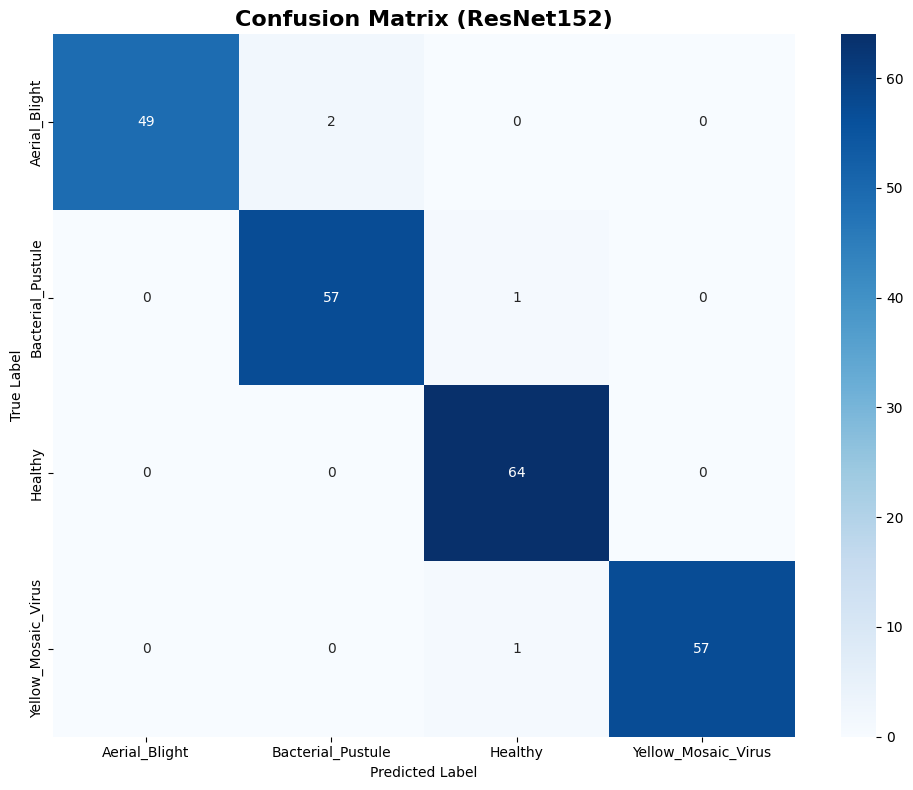


✓ Confusion Matrix saved.


In [ ]:
# ============================================================================
# STEP 9: Comprehensive Evaluation
# ============================================================================
print("\n" + "=" * 70)
print("STEP 9: Comprehensive Evaluation")
print("=" * 70)

test_results = model.evaluate(test_generator, verbose=1)

test_loss = test_results[0]
test_accuracy = test_results[1]
test_auc = test_results[2]

print(f"\n🎯 FINAL TEST RESULTS:")
print(f"    Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"    Test Loss: {test_loss:.4f}")
print(f"    Test AUC: {test_auc:.4f}")

y_pred = []
y_true = []
class_names = create_dataset.class_names
print("Generating predictions for confusion matrix...")

test_iterator = iter(test_generator)
i = 0
while True:
    try:
        images, labels = next(test_iterator)
        preds = model.predict_on_batch(images)

        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        i += 1
        if i % 10 == 0:
            print(f"    Processed {i} batches...")
    except StopIteration:
        break

print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix Visualization
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
             xticklabels=class_names,
             yticklabels=class_names)
plt.title('Confusion Matrix (ResNet152)', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(savepath + 'confusion_matrix_ResNet152.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Confusion Matrix saved.")




STEP 10: Generating visualizations


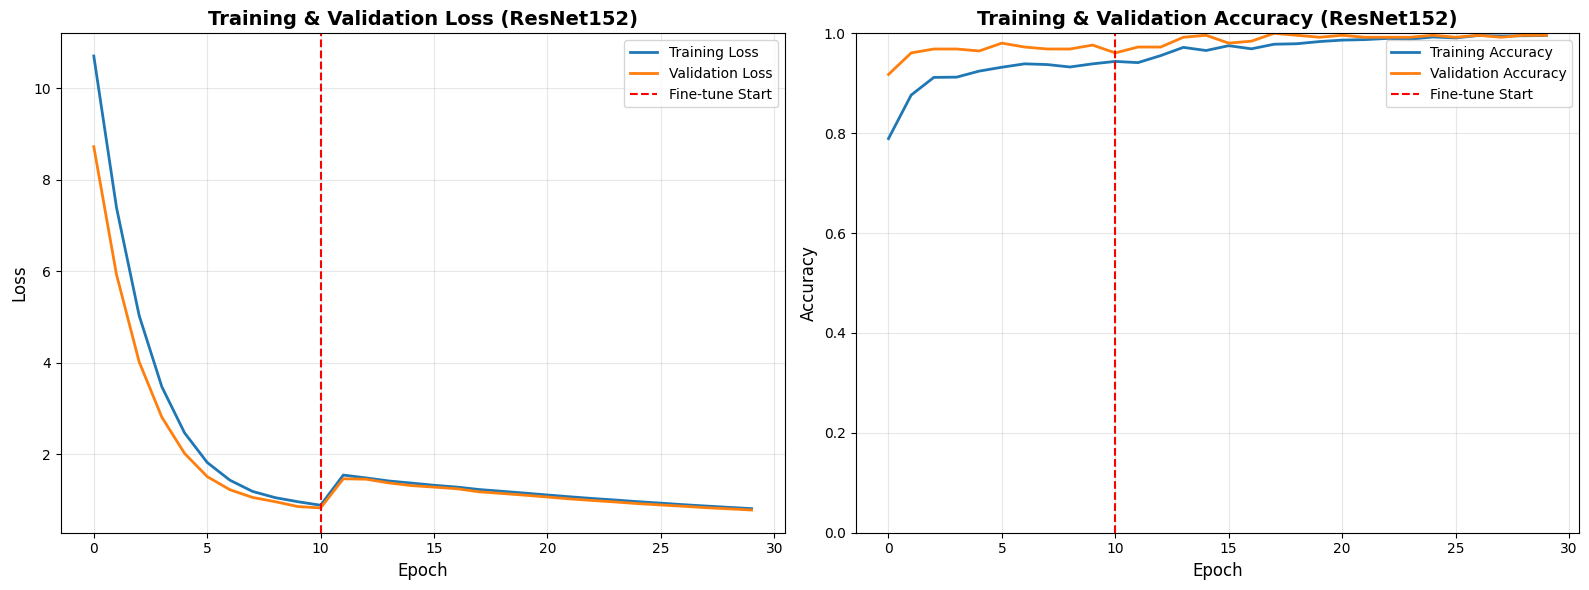


✓ Saved training metrics to: /content/drive/MyDrive/Collabs/SoybeanMultiClass_ResNet152/training_metrics_ResNet152.csv


In [ ]:
# ============================================================================
# STEP 10: Generating visualizations (PLOTTING HISTORY)
# ============================================================================
print("\n" + "=" * 70)
print("STEP 10: Generating visualizations")
print("=" * 70)

class DummyHistory:
    def __init__(self, history):
        self.history = history

def plot_combined_history(hist1, hist2):
    """Combines and plots the training history for both phases."""

    hist1_dict = hist1.history
    hist2_dict = hist2.history

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    total_loss = hist1_dict['loss'] + hist2_dict['loss']
    total_val_loss = hist1_dict['val_loss'] + hist2_dict['val_loss']
    total_acc = hist1_dict['accuracy'] + hist2_dict['accuracy']
    total_val_acc = hist1_dict['val_accuracy'] + hist2_dict['val_accuracy']

    # Loss plot
    axes[0].plot(total_loss, label='Training Loss', linewidth=2)
    axes[0].plot(total_val_loss, label='Validation Loss', linewidth=2)
    axes[0].axvline(x=len(hist1_dict['loss']) - 1, color='red', linestyle='--', label='Fine-tune Start')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training & Validation Loss (ResNet152)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy plot
    axes[1].plot(total_acc, label='Training Accuracy', linewidth=2)
    axes[1].plot(total_val_acc, label='Validation Accuracy', linewidth=2)
    axes[1].axvline(x=len(hist1_dict['loss']) - 1, color='red', linestyle='--', label='Fine-tune Start')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training & Validation Accuracy (ResNet152)', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].set_ylim([0, 1])

    plt.tight_layout()
    plt.savefig(savepath + 'training_history_ResNet152.png', dpi=300, bbox_inches='tight')
    plt.show()

# Execute the plotting function
plot_combined_history(history1, history2)


# Save metrics to CSV
combined_epochs = list(range(1, len(history1.history['loss']) + len(history2.history['loss']) + 1))
df_metrics = pd.DataFrame({
    'epochs': combined_epochs,
    'training_loss': history1.history['loss'] + history2.history['loss'],
    'validation_loss': history1.history['val_loss'] + history2.history['val_loss'],
    'training_accuracy': history1.history['accuracy'] + history2.history['accuracy'],
    'validation_accuracy': history1.history['val_accuracy'] + history2.history['val_accuracy']
})
df_metrics.to_csv(savepath + "training_metrics_ResNet152.csv", sep=',', index=False)
print(f"\n✓ Saved training metrics to: {savepath}training_metrics_ResNet152.csv")